In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [63]:
import mpmath as mp

def inverse_polylog3(y, branch="bose", tol=1e-12):
    """
    Numerically solve for z in:

        Li_3(z) = y

    Parameters
    ----------
    y : float
        Target value.
    branch : str
        "bose"  -> solve Li_3(z) = y for 0 <= z <= 1
        "fermi" -> solve -Li_3(-z) = y for z >= 0
    tol : float
        Numerical tolerance.

    Returns
    -------
    z : mpmath.mpf
        Fugacity-like solution.
    """

    y = mp.mpf(y)

    if branch == "bose":
        # For Bose-Einstein, z is restricted to 0 <= z <= 1
        ymax = mp.zeta(3)

        if y < 0:
            raise ValueError("For the Bose branch, y must be nonnegative.")
        if y > ymax:
            raise ValueError("No Bose solution: Li_3(z) <= zeta(3) for z <= 1.")

        f = lambda z: mp.polylog(3, z) - y

        lo = mp.mpf("0")
        hi = mp.mpf("1")

    elif branch == "fermi":
        # For Fermi-Dirac, solve -Li_3(-z) = y
        if y < 0:
            raise ValueError("For the Fermi branch, y must be nonnegative.")

        f = lambda z: -mp.polylog(3, -z) - y

        lo = mp.mpf("0")
        hi = mp.mpf("1")

        # Expand upper bound until the root is bracketed
        while f(hi) < 0:
            hi *= 2

    else:
        raise ValueError("branch must be either 'bose' or 'fermi'.")

    # Bisection method
    while hi - lo > tol:
        mid = (lo + hi) / 2

        if f(mid) < 0:
            lo = mid
        else:
            hi = mid

    return (lo + hi) / 2

import mpmath as mp

def inverse_polylog1(y, branch="bose", tol=1e-12):
    """
    Numerically solve for z in:

        Li_3(z) = y

    Parameters
    ----------
    y : float
        Target value.
    branch : str
        "bose"  -> solve Li_3(z) = y for 0 <= z <= 1
        "fermi" -> solve -Li_3(-z) = y for z >= 0
    tol : float
        Numerical tolerance.

    Returns
    -------
    z : mpmath.mpf
        Fugacity-like solution.
    """

    y = mp.mpf(y)

    if branch == "bose":
        # For Bose-Einstein, z is restricted to 0 <= z <= 1
        ymax = mp.zeta(3)

        if y < 0:
            raise ValueError("For the Bose branch, y must be nonnegative.")
        if y > ymax:
            raise ValueError("No Bose solution: Li_3(z) <= zeta(3) for z <= 1.")

        f = lambda z: mp.polylog(3, z) - y

        lo = mp.mpf("0")
        hi = mp.mpf("1")

    elif branch == "fermi":
        # For Fermi-Dirac, solve -Li_3(-z) = y
        if y < 0:
            raise ValueError("For the Fermi branch, y must be nonnegative.")

        f = lambda z: -mp.polylog(1, -z) - y

        lo = mp.mpf("0")
        hi = mp.mpf("1")

        # Expand upper bound until the root is bracketed
        while f(hi) < 0:
            hi *= 2

    else:
        raise ValueError("branch must be either 'bose' or 'fermi'.")

    # Bisection method
    while hi - lo > tol:
        mid = (lo + hi) / 2

        if f(mid) < 0:
            lo = mid
        else:
            hi = mid

    return (lo + hi) / 2

import mpmath as mp

# SI constants
kB = 1.380649e-23       # J/K
hbar = 1.054571817e-34  # J*s


def fermi_total_number_1d(mu, T, omega):
    """
    Total particle number for an ideal Fermi gas in a 1D harmonic trap.

    Semiclassical result:
        N = (kB*T / (hbar*omega)) * ln(1 + exp(mu/(kB*T)))

    Parameters
    ----------
    mu : float
        Chemical potential in joules.
    T : float
        Temperature in kelvin.
    omega : float
        Trap angular frequency in rad/s.

    Returns
    -------
    N : mpmath.mpf
        Total particle number.
    """
    beta_mu = mu / (kB * T)
    return (kB * T / (hbar * omega)) * mp.log(1 + mp.e**beta_mu)


def fermi_fugacity_1d_from_N(N, T, omega):
    """
    Solve directly for fugacity z given N for a 1D harmonic trap.

    N = A ln(1 + z), where A = kB*T / (hbar*omega)

    Therefore:
        z = exp(N/A) - 1
    """

    N = mp.mpf(N)
    A = kB * T / (hbar * omega)

    if N <= 0:
        raise ValueError("N must be positive.")

    z = mp.expm1(N / A)
    mu = kB * T * mp.log(z)

    return z, mu

In [25]:
omega = 50 # Hz
kB = 1.380649e-23      # Boltzmann constant, J/K
hbar = 1.054571817e-34 # reduced Planck constant, J*s

N = 1000

g = lambda E : E ** 2 / 2 / (hbar * omega) ** 3

In [62]:
def bose_total_number(z, T, omega_bar):
    """
    Total particle number for an ideal Bose gas in a 3D harmonic trap.

    Energies are measured relative to the ground state.

    N = N0 + Nex

    N0  = z / (1 - z)
    Nex = (kB*T / (hbar*omega_bar))^3 * Li_3(z)

    Parameters
    ----------
    z : float
        Fugacity, 0 < z < 1.
    T : float
        Temperature in kelvin.
    omega_bar : float
        Geometric mean trap frequency in rad/s.

    Returns
    -------
    N : float
        Total particle number.
    """
    z = mp.mpf(z)

    N0 = z / (1 - z)
    Nex = (kB * T / (hbar * omega_bar)) ** 3 * mp.polylog(3, z)

    return N0 + Nex


def find_bose_fugacity(N_target, T, omega_bar, tol=1e-12):
    """
    Solve for fugacity z given total particle number N.

    Finds z satisfying:

        N = z/(1-z) + A*Li_3(z)

    where

        A = (kB*T / (hbar*omega_bar))^3

    Parameters
    ----------
    N_target : float
        Total number of particles.
    T : float
        Temperature in kelvin.
    omega_bar : float
        Geometric mean trap frequency in rad/s.
    tol : float
        Numerical tolerance.

    Returns
    -------
    z : mpmath.mpf
        Fugacity.
    mu : mpmath.mpf
        Chemical potential in joules.
    """

    N_target = mp.mpf(N_target)

    if N_target <= 0:
        raise ValueError("N_target must be positive.")

    # z must lie in (0, 1)
    lo = mp.mpf("0.0")
    hi = mp.mpf("1.0") - mp.mpf("1e-30")

    def f(z):
        return bose_total_number(z, T, omega_bar) - N_target

    # Bisection
    while hi - lo > tol:
        mid = (lo + hi) / 2

        if f(mid) < 0:
            lo = mid
        else:
            hi = mid

    z = (lo + hi) / 2
    mu = kB * T * mp.log(z)

    return z, mu

def bose_total_number_1d(z, T, omega):
    """
    Total particle number for an ideal Bose gas in a 1D harmonic trap.

    Energies are measured relative to the ground state.

    N = N0 + Nex

    N0  = z / (1 - z)
    Nex = -(kB*T / (hbar*omega)) * ln(1 - z)
    """

    z = mp.mpf(z)

    if z <= 0 or z >= 1:
        raise ValueError("For Bose statistics, fugacity must satisfy 0 < z < 1.")

    N0 = z / (1 - z)
    Nex = -(kB * T / (hbar * omega)) * mp.log(1 - z)

    return N0 + Nex


def find_bose_fugacity_1d(N_target, T, omega, tol=1e-12):
    """
    Solve for fugacity z in a 1D harmonic trap:

        N = z/(1-z) - A ln(1-z)

    where

        A = kB*T / (hbar*omega)

    Returns
    -------
    z : mpmath.mpf
        Fugacity.
    mu : mpmath.mpf
        Chemical potential in joules.
    """

    N_target = mp.mpf(N_target)

    if N_target <= 0:
        raise ValueError("N_target must be positive.")

    lo = mp.mpf("1e-50")
    hi = mp.mpf("1.0") - mp.mpf("1e-30")

    def f(z):
        return bose_total_number_1d(z, T, omega) - N_target

    while hi - lo > tol:
        mid = (lo + hi) / 2

        if f(mid) < 0:
            lo = mid
        else:
            hi = mid

    z = (lo + hi) / 2
    mu = kB * T * mp.log(z)

    return z, mu

55.704290546511416
1000.00000000146
0.38191162887888225
55.704290546511416 643.199480221618 0.998979019706997
997.2419504228325
968.565062883382
21.4996562021041


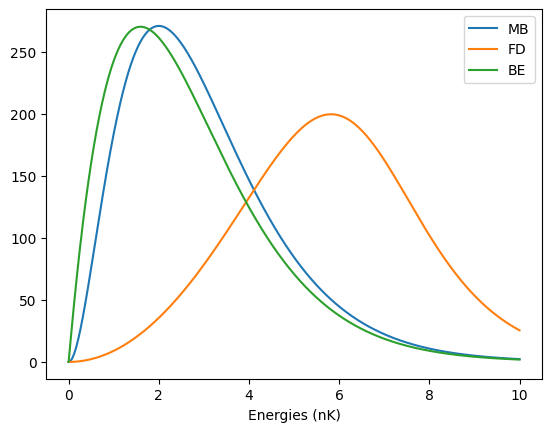

In [53]:
temp = 1e-9 # Kevlin
beta = 1 / temp / kB 

print((hbar * omega * beta) ** 3 * N)

zMB = (hbar * omega * beta) ** 3 * N
zFD = inverse_polylog3((hbar * omega * beta) ** 3 * N, branch='fermi')
zBE, muBE = find_bose_fugacity(N, temp, omega, tol=1e-14)

print(bose_total_number(zBE, temp, omega))

print(beta * hbar * omega)
print(zMB, zFD, zBE)

distMB = lambda E : g(E) * zMB * np.exp(-beta * E)
distFD = lambda E : g(E) / (np.exp(beta * E) / zFD + 1)
distBE = lambda E : g(E) / (np.exp(beta * E) / zBE - 1)

energies = np.linspace(0, kB * temp * 10, 1000)
dE = energies[1] - energies[0]
print(sum(distMB(energies)) * dE)
print(sum(distFD(energies)) * dE)
print(sum(distBE(energies)) * dE)

normalization = 1000 / (sum(distBE(energies)) * dE)

plt.plot(energies / kB * 1e9, distMB(energies) * kB / 1e9, label="MB")
plt.plot(energies / kB * 1e9, distFD(energies) * kB / 1e9, label="FD")
plt.plot(energies / kB * 1e9, distBE(energies) * kB / 1e9 * normalization, label="BE")
plt.xlabel("Energies (nK)")
plt.legend()
plt.savefig("2nK_50Hz.pdf")


5.5704290546511425e-05
20849962.3375375
0.003819116288788823
3.8191162887888233 44.5639251726352 0.974590512204941
1004.9681819341184
1000.75521977601
1015.1518798638


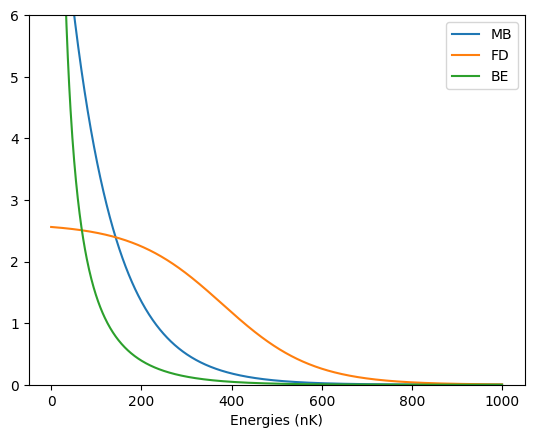

In [74]:
temp = 100e-9 # Kevlin
beta = 1 / temp / kB 

g = lambda E : 1 / hbar / omega

print((hbar * omega * beta) ** 3 * N)

zMB = (hbar * omega * beta) * N
zFD, muFD = fermi_fugacity_1d_from_N(N, temp, omega)
zBE, muBE = find_bose_fugacity_1d(N, temp, omega, tol=1e-12)

print(bose_total_number(zBE, temp, omega))

print(beta * hbar * omega)
print(zMB, zFD, zBE)

distMB = lambda E : g(E) * zMB * np.exp(-beta * E)
distFD = lambda E : g(E) / (np.exp(beta * E) / zFD + 1)
distBE = lambda E : g(E) / (np.exp(beta * E) / zBE - 1)

energies = np.linspace(0, kB * temp * 10, 1000)
dE = energies[1] - energies[0]
print(sum(distMB(energies)) * dE)
print(sum(distFD(energies)) * dE)
print(sum(distBE(energies)) * dE)

normalization = 1000 / (sum(distBE(energies)) * dE)

plt.plot(energies / kB * 1e9, distMB(energies) * kB / 1e9, label="MB")
plt.plot(energies / kB * 1e9, distFD(energies) * kB / 1e9, label="FD")
plt.plot(energies / kB * 1e9, distBE(energies) * kB / 1e9 * normalization, label="BE")
plt.xlabel("Energies (nK)")
plt.legend()
plt.ylim([0, 6])
plt.savefig("2nK_50Hz.pdf")
